# Analyze Library Usage in Agent-Authored PRs

This notebook analyzes how AI coding agents use external libraries in their pull requests.

Research Questions:
1. Do agents happily import and install new libraries?
2. Do they willingly use external libraries that are already installed or do they avoid it?
3. Do they try to commit invalid libraries?
4. Do they specify library versions in their PRs?
5. What are the most common libraries used by agents?

In [1]:
import sys

sys.path.append("..")

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

from src.pr_analyzer import PRAnalyzer

warnings.filterwarnings("ignore")

tqdm.pandas()

data_dir = Path("../data")
output_dir = Path("../output")
output_dir.mkdir(exist_ok=True)

## Load Data

In [2]:
# Load the datasets
print("Loading datasets...")
repo_df = pd.read_parquet(data_dir / "repository.parquet")
pr_df = pd.read_parquet(data_dir / "pull_request.parquet")
commit_details_df = pd.read_parquet(data_dir / "pr_commit_details.parquet")

print(f"Repositories: {len(repo_df):,}")
print(f"Pull Requests: {len(pr_df):,}")
print(f"Commit Details: {len(commit_details_df):,}")

Loading datasets...


Repositories: 2,807
Pull Requests: 33,596
Commit Details: 711,923


## Identify Top 3 Languages

In [3]:
# Merge PR with repository to get language
pr_with_lang = pr_df.merge(
    repo_df[["id", "language"]],
    left_on="repo_id",
    right_on="id",
    how="left",
    suffixes=("", "_repo"),
).drop(columns=["id_repo"])

# Count PRs by language
lang_counts = pr_with_lang["language"].value_counts()
print("Top 10 languages by PR count:")
print(lang_counts.head(10))

# Get top 3
top_3_langs = lang_counts.head(3).index.tolist()
print(f"\nTop 3 languages for analysis: {top_3_langs}")

Top 10 languages by PR count:
language
Go            10108
Python         7191
TypeScript     6503
C#             1985
Java           1278
Rust           1079
JavaScript      987
HTML            755
Ruby            468
C++             422
Name: count, dtype: int64

Top 3 languages for analysis: ['Go', 'Python', 'TypeScript']


## Filter Data to Top 3 Languages

In [4]:
# Filter PRs to top 3 languages
top_lang_prs = pr_with_lang[pr_with_lang["language"].isin(top_3_langs)].copy()
print(f"PRs in top 3 languages: {len(top_lang_prs):,}")

# Get relevant commit details
pr_ids = set(top_lang_prs["id"])
top_commits = commit_details_df[commit_details_df["pr_id"].isin(pr_ids)].copy()

# Rename pr_id to pull_request_id for compatibility with PRAnalyzer
top_commits = top_commits.rename(columns={"pr_id": "pull_request_id"})

print(f"Commit details in top 3 languages: {len(top_commits):,}")

PRs in top 3 languages: 23,802


Commit details in top 3 languages: 463,816


## Analyze Library Usage by Language

In [5]:
analyzer = PRAnalyzer()
results_by_language = {}

for lang in top_3_langs:
    print(f"\n{'=' * 60}")
    print(f"Analyzing {lang}...")
    print("=" * 60)

    # Get PRs and commits for this language
    lang_pr_ids = set(top_lang_prs[top_lang_prs["language"] == lang]["id"])
    lang_commits = top_commits[top_commits["pull_request_id"].isin(lang_pr_ids)]

    print(f"PRs: {len(lang_pr_ids):,}")
    print(f"File changes: {len(lang_commits):,}")

    # Analyze
    print("\nAnalyzing library usage...")
    results = analyzer.analyze_commit_details(lang_commits, lang)

    # Merge with agent info
    for pr_id, usage in results.items():
        pr_info = top_lang_prs[top_lang_prs["id"] == pr_id]
        if len(pr_info) > 0 and "agent" in pr_info.columns:
            usage.agent = pr_info.iloc[0]["agent"]

    results_by_language[lang] = list(results.values())
    print(f"Analyzed {len(results):,} PRs")


Analyzing Go...
PRs: 10,108
File changes: 182,144

Analyzing library usage...


Analyzed 10,107 PRs

Analyzing Python...
PRs: 7,191
File changes: 91,031

Analyzing library usage...


Analyzed 7,190 PRs

Analyzing TypeScript...
PRs: 6,503
File changes: 190,641

Analyzing library usage...


Analyzed 6,494 PRs


## Generate Statistics

In [6]:
stats_by_language = {}

for lang, usages in results_by_language.items():
    print(f"\n{'=' * 60}")
    print(f"{lang} Statistics")
    print("=" * 60)

    stats = PRAnalyzer.aggregate_statistics(usages)
    stats_by_language[lang] = stats

    print(f"\nTotal PRs: {stats['total_prs']:,}")
    print(
        f"PRs with new libraries: {stats['prs_with_new_libs']:,} ({stats['pct_prs_with_new_libs']:.1f}%)"
    )
    print(
        f"PRs with dependency changes: {stats['prs_with_dep_changes']:,} ({stats['pct_prs_with_dep_changes']:.1f}%)"
    )
    print(f"PRs adding dep file: {stats['prs_adding_dep_file']:,}")
    print(f"PRs modifying dep file: {stats['prs_modifying_dep_file']:,}")

    print(f"\nUnique libraries: {stats['total_unique_libs']:,}")
    print(f"External libraries: {stats['total_external_libs']:,}")
    print(f"Stdlib imports: {stats['total_stdlib_imports']:,}")

    print(f"\nAvg libraries per PR: {stats['avg_libs_per_pr']:.2f}")
    print(f"Avg new libraries per PR: {stats['avg_new_libs_per_pr']:.2f}")

    print(f"\nLibraries with version: {stats['total_libs_with_version']:,}")
    print(f"Libraries without version: {stats['total_libs_without_version']:,}")
    print(f"% with version: {stats['pct_libs_with_version']:.1f}%")

    if stats["version_operators"]:
        print("\nVersion operators:")
        for op, count in stats["version_operators"].most_common():
            print(f"  {op}: {count}")

    print("\nMost common libraries:")
    for lib, count in stats["most_common_libs"][:10]:
        print(f"  {lib}: {count}")

    print("\nMost common new libraries:")
    for lib, count in stats["most_common_new_libs"][:10]:
        print(f"  {lib}: {count}")


Go Statistics

Total PRs: 10,107
PRs with new libraries: 16 (0.2%)
PRs with dependency changes: 181 (1.8%)
PRs adding dep file: 3
PRs modifying dep file: 181

Unique libraries: 696
External libraries: 641
Stdlib imports: 55

Avg libraries per PR: 0.97
Avg new libraries per PR: 0.02

Libraries with version: 203
Libraries without version: 0
% with version: 100.0%

Most common libraries:
  fmt: 853
  testing: 727
  os: 716
  strings: 685
  path/filepath: 602
  mochi/parser: 576
  bytes: 559
  mochi/types: 512
  os/exec: 495
  time: 247

Most common new libraries:
  github.com/golang/snappy: 6
  github.com/stretchr/testify: 3
  gopkg.in/yaml.v3: 3
  github.com/klauspost/reedsolomon: 3
  github.com/gogo/protobuf: 3
  go.uber.org/atomic: 2
  github.com/smacker/go-tree-sitter: 2
  github.com/alingse/asasalint: 1
  github.com/gobwas/glob: 1
  github.com/go-toolsmith/typep: 1

Python Statistics

Total PRs: 7,190
PRs with new libraries: 122 (1.7%)
PRs with dependency changes: 673 (9.4%)
PRs add

## Visualizations

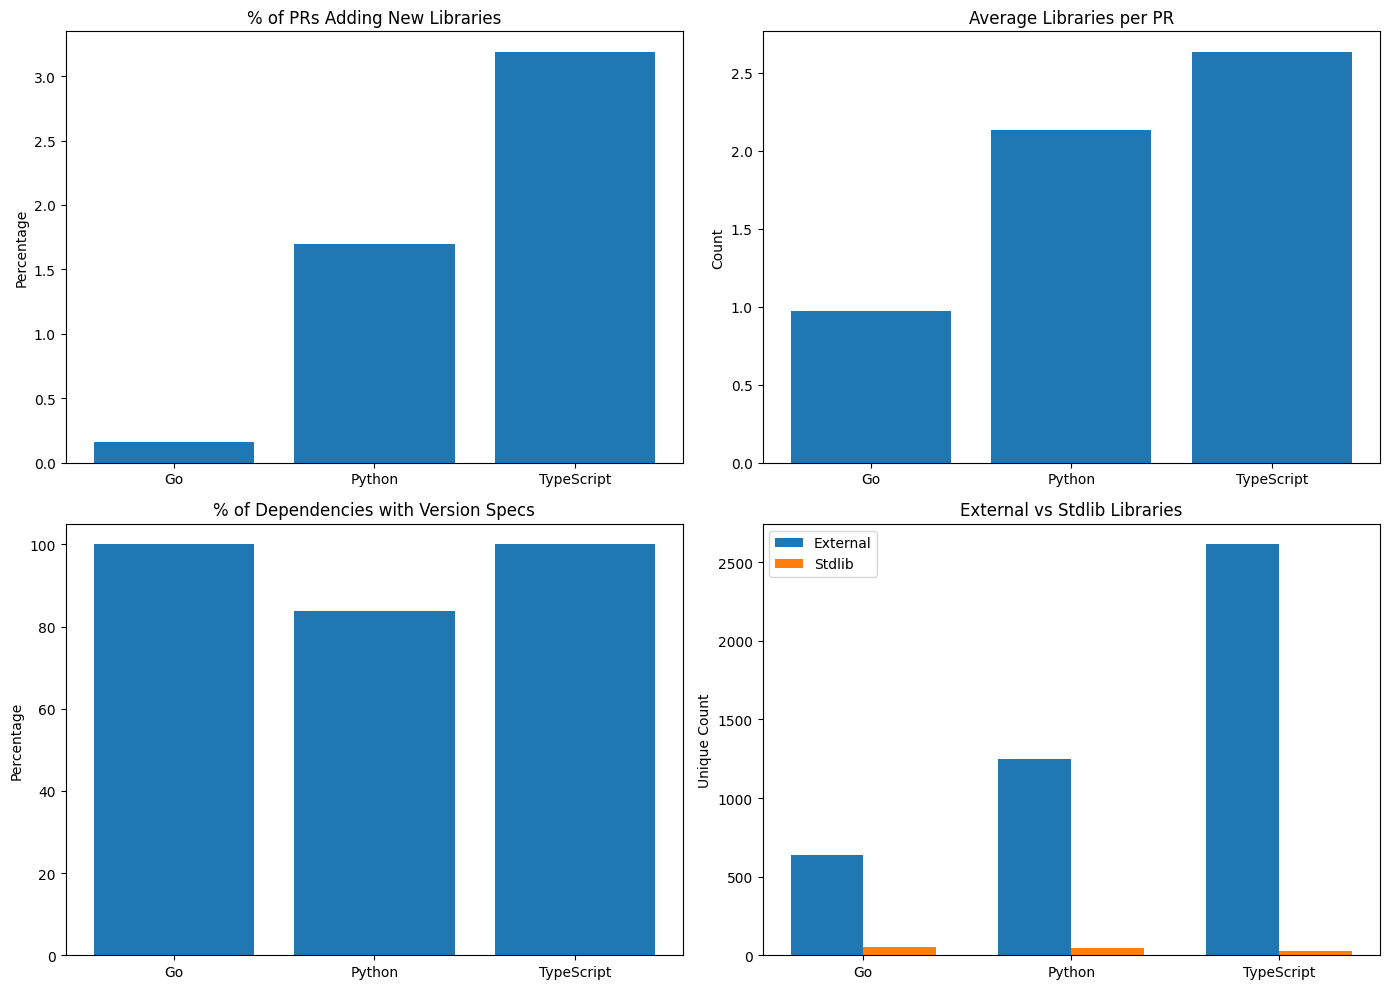

In [7]:
# Library usage comparison across languages
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. PRs with new libraries
langs = list(stats_by_language.keys())
pct_with_new = [stats_by_language[lang]["pct_prs_with_new_libs"] for lang in langs]
axes[0, 0].bar(langs, pct_with_new)
axes[0, 0].set_title("% of PRs Adding New Libraries")
axes[0, 0].set_ylabel("Percentage")

# 2. Avg libraries per PR
avg_libs = [stats_by_language[lang]["avg_libs_per_pr"] for lang in langs]
axes[0, 1].bar(langs, avg_libs)
axes[0, 1].set_title("Average Libraries per PR")
axes[0, 1].set_ylabel("Count")

# 3. % with version specs
pct_versioned = [stats_by_language[lang]["pct_libs_with_version"] for lang in langs]
axes[1, 0].bar(langs, pct_versioned)
axes[1, 0].set_title("% of Dependencies with Version Specs")
axes[1, 0].set_ylabel("Percentage")

# 4. External vs Stdlib ratio
external_counts = [stats_by_language[lang]["total_external_libs"] for lang in langs]
stdlib_counts = [stats_by_language[lang]["total_stdlib_imports"] for lang in langs]
x = range(len(langs))
width = 0.35
axes[1, 1].bar([i - width / 2 for i in x], external_counts, width, label="External")
axes[1, 1].bar([i + width / 2 for i in x], stdlib_counts, width, label="Stdlib")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(langs)
axes[1, 1].set_title("External vs Stdlib Libraries")
axes[1, 1].set_ylabel("Unique Count")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(output_dir / "library_usage_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Save Results

In [8]:
# Save detailed results
for lang, usages in results_by_language.items():
    # Convert to list of dicts
    results_list = [u.to_dict() for u in usages]

    # Save as JSON
    output_file = output_dir / f"{lang.lower()}_library_usage.json"
    with open(output_file, "w") as f:
        json.dump(results_list, f, indent=2)
    print(f"Saved {lang} results to {output_file}")

# Save aggregated statistics
stats_file = output_dir / "aggregated_statistics.json"
# Convert Counter objects to dicts for JSON serialization
stats_serializable = {}
for lang, stats in stats_by_language.items():
    stats_copy = stats.copy()
    if "version_operators" in stats_copy:
        stats_copy["version_operators"] = dict(stats_copy["version_operators"])
    stats_serializable[lang] = stats_copy

with open(stats_file, "w") as f:
    json.dump(stats_serializable, f, indent=2)
print(f"\nSaved aggregated statistics to {stats_file}")

Saved Go results to ../output/go_library_usage.json
Saved Python results to ../output/python_library_usage.json


Saved TypeScript results to ../output/typescript_library_usage.json

Saved aggregated statistics to ../output/aggregated_statistics.json


## Summary of Findings

This section will be updated after running the analysis with key insights about:

1. **Library Adoption**: Do agents readily add new libraries?
2. **Existing Libraries**: Do agents use already-installed libraries or avoid dependencies?
3. **Version Specifications**: How often do agents specify versions?
4. **Most Common Libraries**: What are the go-to libraries for each language?
5. **Invalid Libraries**: Pattern detection for potentially invalid dependencies